# Análise dos resultados da avaliação

Lê os 15 batches em `batches_eval/` (5 por edital), junta tudo, faz merge da `categoria` (vinda de `df_avaliacoes.xlsx`) e produz uma bateria completa de análises.

Estrutura:

1. **Setup & carga** — leitura dos 15 batches + merge da categoria.
2. **Sanity checks** — schema, contagens, scores no domínio.
3. **Distribuição global** de scores.
4. **Ranking por modelo** (150 perguntas cada) — análise principal.
5. **Modelo × edital**.
6. **Modelo × categoria**.
7. **Comparativas**: chats vs APIs, por provider.
8. **Análise por pergunta**: mais difíceis, mais fáceis, maior discordância.
9. **Padrões de erro** nas justificativas.
10. **Sumário & exporte**.


## 1. Setup & carga

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', context='notebook')

# === AJUSTE OS PATHS SE PRECISAR ===
# Use caminho absoluto pra não depender de onde o kernel foi iniciado
NB_DIR = Path('/home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/avaliacao_chats_comerciais').resolve()
EVAL_DIR = NB_DIR / 'batches_eval'
CATEGORIA_SRC = NB_DIR.parent / 'avaliacao_llms' / 'df_avaliacoes.xlsx'
OUT_DIR = NB_DIR / 'analise_out'
OUT_DIR.mkdir(exist_ok=True)

EDITAIS = ['bndes', 'cvm', 'petrobras']
N_BATCHES = 5

# valida que os 15 batches existem
faltando = []
for ed in EDITAIS:
    for i in range(1, N_BATCHES + 1):
        p = EVAL_DIR / f'{ed}_batch_{i:02d}_eval.xlsx'
        if not p.exists():
            faltando.append(p.name)
assert not faltando, f'arquivos faltando em {EVAL_DIR}: {faltando}'
assert CATEGORIA_SRC.exists(), f'não achei {CATEGORIA_SRC}'
print(f'NB_DIR    = {NB_DIR}')
print(f'EVAL_DIR  = {EVAL_DIR}')
print('15 batches encontrados, OK')


NB_DIR    = /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/avaliacao_chats_comerciais
EVAL_DIR  = /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/avaliacao_chats_comerciais/batches_eval
15 batches encontrados, OK


In [2]:
# Lê os 15 batches e concatena
partes = []
for ed in EDITAIS:
    for i in range(1, N_BATCHES + 1):
        p = EVAL_DIR / f'{ed}_batch_{i:02d}_eval.xlsx'
        d = pd.read_excel(p)
        d['edital'] = ed
        d['batch'] = i
        partes.append(d)
df = pd.concat(partes, ignore_index=True)
print(f'concatenado: {len(df)} linhas')

# Normaliza score (vírgula → ponto, string → float)
df['score'] = pd.to_numeric(df['score'].astype(str).str.replace(',', '.'), errors='coerce')

# Merge categoria
cat_map = (pd.read_excel(CATEGORIA_SRC)[['edital', 'id', 'categoria']]
             .drop_duplicates(['edital', 'id']))
df = df.merge(cat_map, on=['edital', 'id'], how='left')

df = df[['edital', 'id', 'categoria', 'pergunta', 'modelo', 'resposta', 'score', 'justificativa', 'batch']]
df.head(3)


concatenado: 1650 linhas


,edital,id,categoria,pergunta,modelo,resposta,score,justificativa,batch
0,bndes,1,Dados sobre as inscrições,Qual o período de inscrição para o concurso BN...,claude-haiku-4-5,**Período de inscrição do BNDES (01/2024):**\n...,0.5,item 6.2.1 fixa inscrição de 10h de 26/07/2024...,1
1,bndes,1,Dados sobre as inscrições,Qual o período de inscrição para o concurso BN...,claude-opus-4-7,O período de inscrição para o concurso BNDES (...,0.5,item 6.2.1 fixa inscrição de 10h de 26/07/2024...,1
2,bndes,1,Dados sobre as inscrições,Qual o período de inscrição para o concurso BN...,claude-sonnet-4-6,Aqui estão as informações sobre o período de i...,0.5,item 6.2.1 fixa inscrição de 10h de 26/07/2024...,1


## 2. Sanity checks

In [3]:
print(f'linhas totais:    {len(df)}  (esperado: 1650 = 3 × 50 × 11)')
print(f'editais:          {sorted(df.edital.unique())}')
print(f'modelos ({df.modelo.nunique()}):   {sorted(df.modelo.unique())}')
print(f'categorias:       {df.categoria.nunique()}')
print(f'scores únicos:    {sorted(df.score.dropna().unique())}')
print(f'nulos score:      {df.score.isna().sum()}')
print(f'nulos categoria:  {df.categoria.isna().sum()}')
print(f'just. vazias:     {df.justificativa.isna().sum() + (df.justificativa.astype(str).str.strip()=="").sum()}')

cont = df.groupby('modelo').size()
print(f'\nlinhas por modelo (esperado 150):')
print(cont.sort_values().to_string())

# assertions críticas — falham alto se algo está fora
assert len(df) == 1650, f'esperado 1650, veio {len(df)}'
assert (cont == 150).all(), 'algum modelo não tem exatamente 150 avaliações'
assert df['score'].dropna().isin([0, 0.5, 1]).all(), 'score fora de {0, 0.5, 1}'
assert df['categoria'].isna().sum() == 0, 'tem linhas sem categoria — merge falhou'
print('\nsanity OK')


linhas totais:    1650  (esperado: 1650 = 3 × 50 × 11)
editais:          ['bndes', 'cvm', 'petrobras']
modelos (11):   ['chatgpt', 'claude-haiku-4-5', 'claude-opus-4-7', 'claude-sonnet-4-6', 'claude_chat', 'deepseek-v4-flash', 'deepseek-v4-pro', 'gpt-4o-mini', 'gpt-5.4', 'gpt-5.4-mini', 'gpt-5.5']
categorias:       5
scores únicos:    [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
nulos score:      0
nulos categoria:  0
just. vazias:     0

linhas por modelo (esperado 150):
modelo
chatgpt              150
claude-haiku-4-5     150
claude-opus-4-7      150
claude-sonnet-4-6    150
claude_chat          150
deepseek-v4-flash    150
deepseek-v4-pro      150
gpt-4o-mini          150
gpt-5.4              150
gpt-5.4-mini         150
gpt-5.5              150

sanity OK


## 3. Distribuição global de scores

Antes de comparar modelos, ver o agregado: o conjunto está enviesado? Algum edital foi consistentemente mais difícil?


In [4]:
dist_geral = df['score'].value_counts(normalize=True).sort_index() * 100
print('distribuição global (%):')
print(dist_geral.round(1).to_string())
print(f'\nmédia global: {df.score.mean():.3f}')


distribuição global (%):
score
0.0     2.9
0.5    46.3
1.0    50.8

média global: 0.739


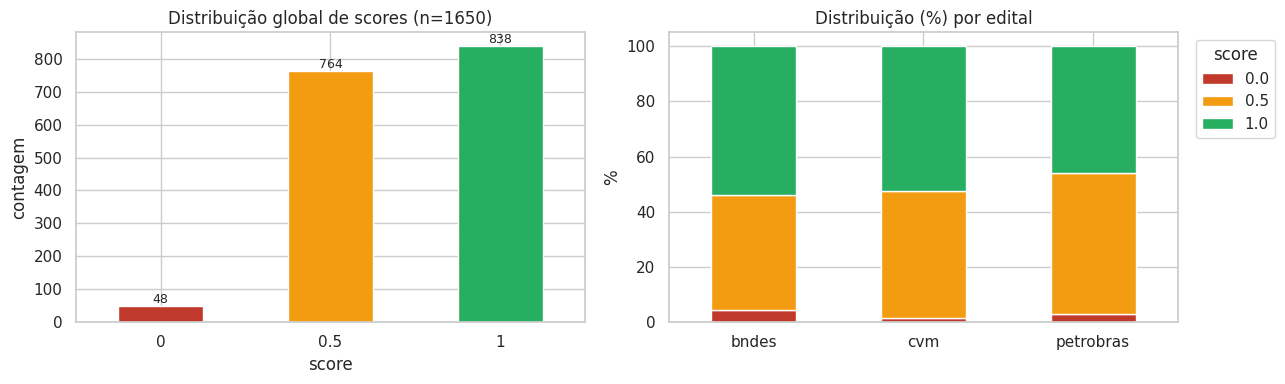


média por edital:
edital
bndes        0.748
cvm          0.755
petrobras    0.715


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['score'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
                                              color=['#c0392b', '#f39c12', '#27ae60'])
axes[0].set_title('Distribuição global de scores (n=1650)')
axes[0].set_xlabel('score'); axes[0].set_ylabel('contagem')
axes[0].set_xticklabels(['0', '0.5', '1'], rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

tab = df.groupby(['edital', 'score']).size().unstack(fill_value=0)
tab_pct = tab.div(tab.sum(axis=1), axis=0) * 100
tab_pct.plot(kind='bar', stacked=True, ax=axes[1],
             color=['#c0392b', '#f39c12', '#27ae60'])
axes[1].set_title('Distribuição (%) por edital')
axes[1].set_ylabel('%'); axes[1].set_xlabel('')
axes[1].legend(title='score', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout(); plt.show()

print('\nmédia por edital:')
print(df.groupby('edital')['score'].mean().round(3).to_string())


média por categoria:
                           media    n
categoria                            
Dados sobre Procedimentos  0.800  165
Dados sobre o Cargo        0.786  429
Dados sobre a Prova        0.724  495
Dados sobre o Concurso     0.721  231
Dados sobre as inscrições  0.685  330


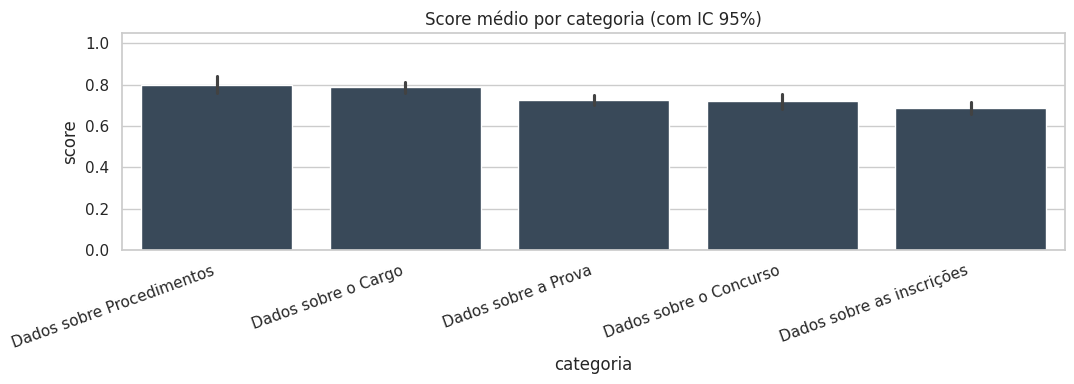

In [6]:
cat_summary = (df.groupby('categoria')
                 .agg(media=('score', 'mean'), n=('score', 'size'))
                 .sort_values('media', ascending=False)
                 .round(3))
print('média por categoria:')
print(cat_summary.to_string())

plt.figure(figsize=(11, 4))
sns.barplot(data=df, x='categoria', y='score', errorbar=('ci', 95),
            order=cat_summary.index, color='#34495e')
plt.title('Score médio por categoria (com IC 95%)')
plt.xticks(rotation=20, ha='right'); plt.ylim(0, 1.05)
plt.tight_layout(); plt.show()


## 4. Ranking por modelo — análise principal

Cada modelo respondeu **150 perguntas** (50 × 3 editais). Esta seção é a que importa.


In [7]:
rank = (df.groupby('modelo')
          .agg(media=('score', 'mean'),
               n=('score', 'size'),
               soma=('score', 'sum'))
          .round(3))

dist = (df.groupby(['modelo', 'score']).size().unstack(fill_value=0)
          .rename(columns={0.0: 'errado', 0.5: 'parcial', 1.0: 'certo'}))
dist_pct = dist.div(dist.sum(axis=1), axis=0).mul(100).round(1)
dist_pct.columns = [c + '_%' for c in dist_pct.columns]

ranking = rank.join(dist).join(dist_pct).sort_values('media', ascending=False)
ranking


,media,n,soma,errado,parcial,certo,errado_%,parcial_%,certo_%
modelo,,,,,,,,,
gpt-5.5,0.930,150,139.5,0,21,129,0.0,14.0,86.0
gpt-5.4,0.927,150,139.0,3,16,131,2.0,10.7,87.3
chatgpt,0.833,150,125.0,16,18,116,10.7,12.0,77.3
gpt-5.4-mini,0.820,150,123.0,9,36,105,6.0,24.0,70.0
gpt-4o-mini,0.760,150,114.0,10,52,88,6.7,34.7,58.7
deepseek-v4-pro,0.693,150,104.0,1,90,59,0.7,60.0,39.3
deepseek-v4-flash,0.690,150,103.5,3,87,60,2.0,58.0,40.0
claude-haiku-4-5,0.677,150,101.5,3,91,56,2.0,60.7,37.3
claude-opus-4-7,0.673,150,101.0,0,98,52,0.0,65.3,34.7


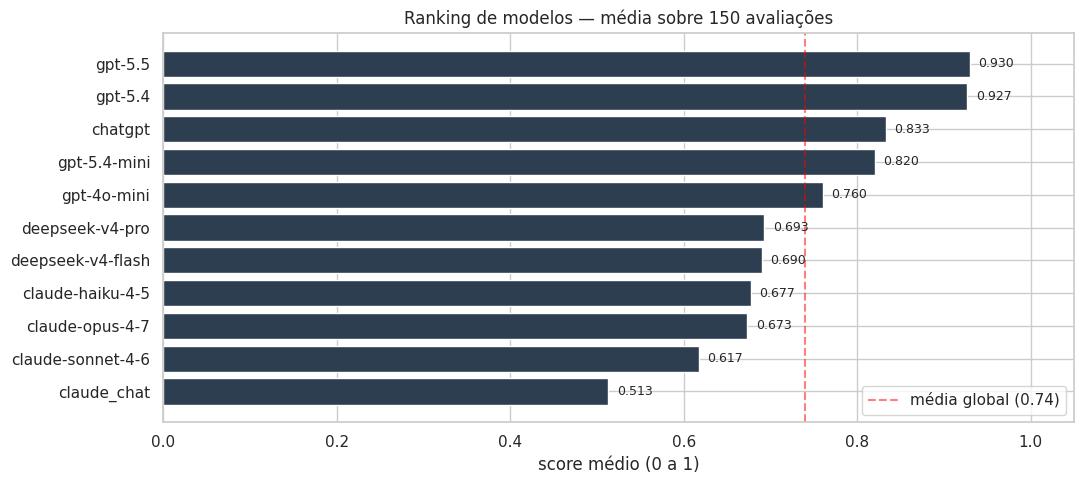

In [8]:
# Ranking — gráfico-chefe
fig, ax = plt.subplots(figsize=(11, 5))
order = ranking.index.tolist()
bars = ax.barh(order, ranking['media'], color='#2c3e50')
ax.invert_yaxis()
ax.set_xlim(0, 1.05)
ax.set_xlabel('score médio (0 a 1)')
ax.set_title('Ranking de modelos — média sobre 150 avaliações')
ax.axvline(df.score.mean(), color='red', linestyle='--', alpha=0.5,
           label=f'média global ({df.score.mean():.2f})')
for bar, val in zip(bars, ranking['media']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=9)
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()


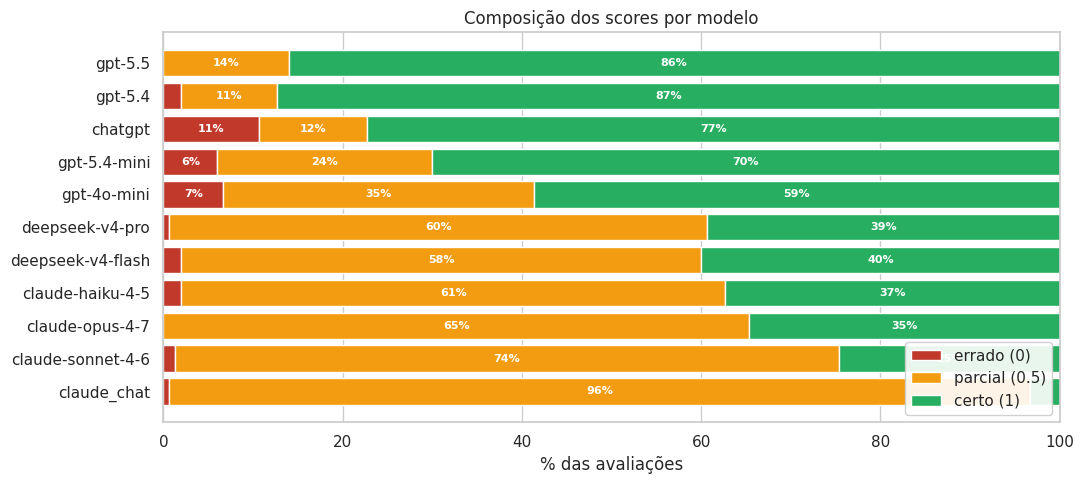

In [9]:
# Distribuição 1 / 0.5 / 0 por modelo
dist_pct_plot = df.groupby(['modelo', 'score']).size().unstack(fill_value=0)
dist_pct_plot = dist_pct_plot.div(dist_pct_plot.sum(axis=1), axis=0) * 100
dist_pct_plot = dist_pct_plot.loc[order]

fig, ax = plt.subplots(figsize=(11, 5))
left = np.zeros(len(dist_pct_plot))
colors = {0.0: '#c0392b', 0.5: '#f39c12', 1.0: '#27ae60'}
labels = {0.0: 'errado (0)', 0.5: 'parcial (0.5)', 1.0: 'certo (1)'}
for s in [0.0, 0.5, 1.0]:
    if s in dist_pct_plot.columns:
        vals = dist_pct_plot[s].values
        ax.barh(dist_pct_plot.index, vals, left=left, color=colors[s], label=labels[s])
        for i, v in enumerate(vals):
            if v >= 4:
                ax.text(left[i] + v/2, i, f'{v:.0f}%', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        left += vals

ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel('% das avaliações')
ax.set_title('Composição dos scores por modelo')
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout(); plt.show()


## 5. Modelo × Edital

Modelo **consistente** tem score parecido nos 3 editais (`desvio` baixo). Modelo que brilha em um e desaba em outro pula no olho.


In [10]:
mat = df.pivot_table(index='modelo', columns='edital', values='score', aggfunc='mean').round(3)
mat['média']  = df.groupby('modelo')['score'].mean().round(3)
mat['desvio'] = mat[EDITAIS].std(axis=1).round(3)
mat = mat.sort_values('média', ascending=False)
mat


edital,bndes,cvm,petrobras,média,desvio
modelo,,,,,
gpt-5.5,0.94,0.92,0.93,0.930,0.010
gpt-5.4,0.92,0.89,0.97,0.927,0.040
chatgpt,0.66,0.97,0.87,0.833,0.158
gpt-5.4-mini,0.84,0.82,0.80,0.820,0.020
gpt-4o-mini,0.77,0.82,0.69,0.760,0.066
deepseek-v4-pro,0.77,0.68,0.63,0.693,0.071
deepseek-v4-flash,0.69,0.73,0.65,0.690,0.040
claude-haiku-4-5,0.72,0.71,0.60,0.677,0.067
claude-opus-4-7,0.77,0.63,0.62,0.673,0.084


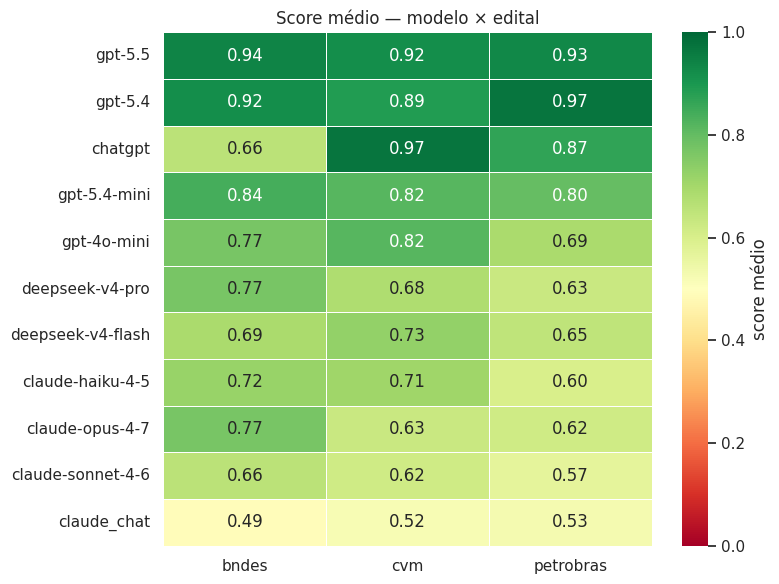

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(mat[EDITAIS].loc[order], annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=0, vmax=1, cbar_kws={'label': 'score médio'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Score médio — modelo × edital')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.show()


## 6. Modelo × Categoria

Onde cada modelo é forte/fraco. Coluna inteira vermelha = categoria difícil pra todos; célula vermelha isolada = buraco específico daquele modelo.


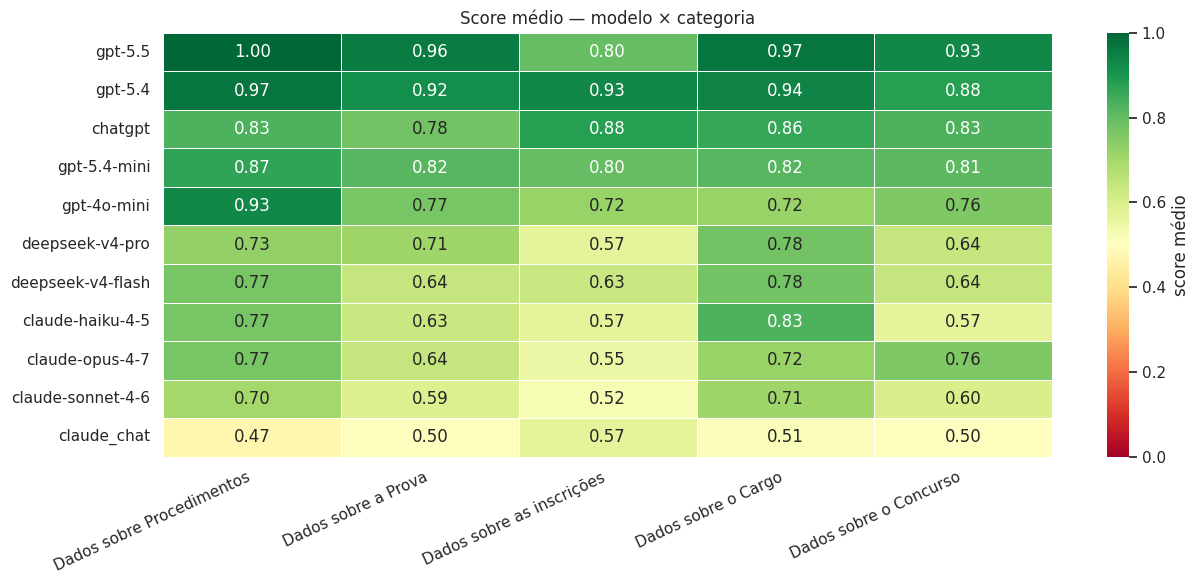


categorias mais difíceis (média entre todos os modelos):
categoria
Dados sobre as inscrições    0.685
Dados sobre o Concurso       0.721
Dados sobre a Prova          0.724
Dados sobre o Cargo          0.786
Dados sobre Procedimentos    0.800


In [12]:
mat_cat = df.pivot_table(index='modelo', columns='categoria', values='score', aggfunc='mean').round(2)
mat_cat = mat_cat.loc[order]

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(mat_cat, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label': 'score médio'}, ax=ax, linewidths=0.5, linecolor='white')
ax.set_title('Score médio — modelo × categoria')
ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()

print('\ncategorias mais difíceis (média entre todos os modelos):')
print(df.groupby('categoria')['score'].mean().sort_values().round(3).to_string())


## 7. Análises comparativas

### 7.1. Chats comerciais vs APIs/modelos
Hipótese inicial: chats (ChatGPT, Claude) extrapolam mais e ancoram menos no edital.


      media     n
tipo             
api   0.754  1350
chat  0.673   300


/tmp/ipykernel_28644/297746498.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='tipo', y='score', errorbar=('ci', 95),


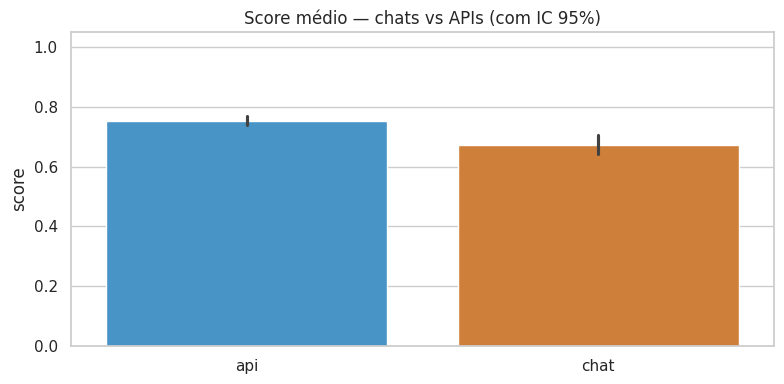

In [13]:
def classifica(m):
    return 'chat' if m in ('chatgpt', 'claude_chat') else 'api'

df['tipo'] = df['modelo'].apply(classifica)

comp_tipo = (df.groupby('tipo')
               .agg(media=('score', 'mean'), n=('score', 'size'))
               .round(3))
print(comp_tipo.to_string())

plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='tipo', y='score', errorbar=('ci', 95),
            palette={'api': '#3498db', 'chat': '#e67e22'})
plt.title('Score médio — chats vs APIs (com IC 95%)')
plt.ylim(0, 1.05); plt.ylabel('score'); plt.xlabel('')
plt.tight_layout(); plt.show()


### 7.2. Por provider

           media    n
provider             
openai     0.854  750
deepseek   0.692  300
anthropic  0.620  600


/tmp/ipykernel_28644/219048947.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='provider', y='score', errorbar=('ci', 95),


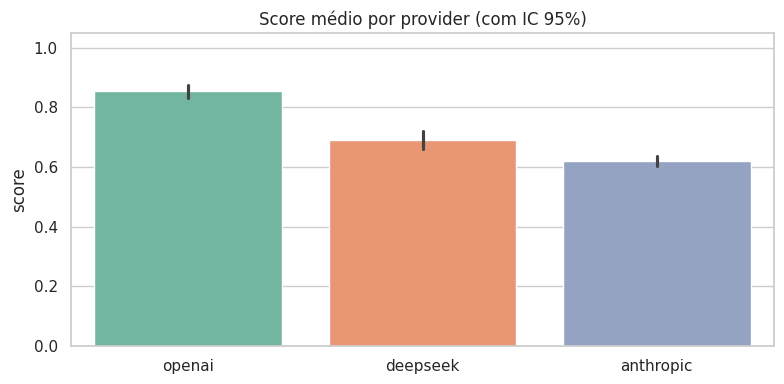

In [14]:
def provider(m):
    if m.startswith('claude') or m == 'claude_chat': return 'anthropic'
    if m.startswith('gpt') or m == 'chatgpt':        return 'openai'
    if m.startswith('deepseek'):                     return 'deepseek'
    return 'outro'

df['provider'] = df['modelo'].apply(provider)

comp_prov = (df.groupby('provider')
               .agg(media=('score', 'mean'), n=('score', 'size'))
               .sort_values('media', ascending=False)
               .round(3))
print(comp_prov.to_string())

plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='provider', y='score', errorbar=('ci', 95),
            order=comp_prov.index, palette='Set2')
plt.title('Score médio por provider (com IC 95%)')
plt.ylim(0, 1.05); plt.ylabel('score'); plt.xlabel('')
plt.tight_layout(); plt.show()


## 8. Análise por pergunta

### 8.1. Mais difíceis e mais fáceis (média entre os 11 modelos)


In [ ]:
perg = (df.groupby(['edital', 'id', 'categoria', 'pergunta'])
          .agg(media=('score', 'mean'), n_certos=('score', lambda s: (s == 1).sum()))
          .round(3)---------------------------------------------------------------------------
AssertionError                            Traceback (most recent call last)
Cell In[1], line 24
     21 OUT_DIR.mkdir(exist_ok=True)
     23 for k, p in EVAL_FILES.items():
---> 24     assert p.exists(), f'não achei {p}'
     25 assert CATEGORIA_SRC.exists(), f'não achei {CATEGORIA_SRC}'
     26 print('paths OK')

AssertionError: não achei /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/avaliacao_chats_comerciais/batches_eval/bndes_eval_final.xlsx
          .reset_index())

print('=== 15 PERGUNTAS MAIS DIFÍCEIS ===')
print(perg.sort_values('media').head(15)
        [['edital', 'id', 'categoria', 'media', 'n_certos', 'pergunta']].to_string(index=False))

print('\n=== PERGUNTAS QUE TODOS ACERTARAM (média = 1.0) ===')
trivial = perg[perg['media'] == 1.0]
print(f'total: {len(trivial)} perguntas')
print(trivial[['edital', 'id', 'categoria', 'pergunta']].head(10).to_string(index=False))


=== 15 PERGUNTAS MAIS DIFÍCEIS ===
   edital  id                 categoria  media  n_certos                                                                                    pergunta
    bndes  10 Dados sobre as inscrições  0.364         1      O candidato precisa guardar o comprovante de inscrição ou pagamento do concurso BNDES?
    bndes   9 Dados sobre as inscrições  0.455         1                             O candidato pode fazer mais de uma inscrição no concurso BNDES?
petrobras  12    Dados sobre o Concurso  0.455         2                                           Quantas fases ou etapas tem o concurso PETROBRAS?
petrobras   1 Dados sobre as inscrições  0.500         1                                      Qual o período de inscrição para o concurso PETROBRAS?
petrobras  25       Dados sobre o Cargo  0.545         2                                Qual é a jornada de trabalho do cargo no concurso PETROBRAS?
      cvm  24       Dados sobre o Cargo  0.545         4               

### 8.2. Maior discordância entre modelos
Variância alta = modelos respondem coisas muito diferentes. Bons candidatos pra inspeção manual.


In [16]:
var = (df.groupby(['edital', 'id', 'categoria', 'pergunta'])['score']
         .agg(['mean', 'std'])
         .round(3).reset_index()
         .sort_values('std', ascending=False))

print('=== 15 PERGUNTAS COM MAIOR DESVIO ENTRE MODELOS ===')
print(var.head(15)[['edital', 'id', 'categoria', 'mean', 'std', 'pergunta']].to_string(index=False))


=== 15 PERGUNTAS COM MAIOR DESVIO ENTRE MODELOS ===
   edital  id              categoria  mean   std                                                                               pergunta
      cvm  24    Dados sobre o Cargo 0.545 0.416                             Qual é o regime de contratação ou vínculo do concurso CVM?
    bndes  42    Dados sobre a Prova 0.727 0.410                              Quantos pontos vale a prova discursiva do concurso BNDES?
    bndes  30    Dados sobre o Cargo 0.682 0.405  Quais são as atribuições gerais do cargo ligado à Ciência de Dados no concurso BNDES?
    bndes  45    Dados sobre a Prova 0.636 0.393                 Como é calculada a nota final do concurso BNDES para Ciência de Dados?
      cvm  39    Dados sobre a Prova 0.636 0.393                          Existe penalidade por erro na prova objetiva do concurso CVM?
    bndes  44    Dados sobre a Prova 0.591 0.375     Quantas provas discursivas de Ciência de Dados serão corrigidas no concurso BND

## 9. Padrões de erro nas justificativas

O prompt pediu, quando score ≠ 1, que a justificativa nomeasse o problema com uma destas etiquetas: **enrolou, inferiu, inventou, errou, fora de escopo**.


In [17]:
PADROES = ['enrolou', 'inferiu', 'inventou', 'errou', 'fora de escopo']

def detecta_padroes(texto):
    t = str(texto).lower()
    return {p: int(p in t) for p in PADROES}

ruins = df[df['score'] != 1].copy()
flags = ruins['justificativa'].apply(detecta_padroes).apply(pd.Series)
ruins = pd.concat([ruins.reset_index(drop=True), flags.reset_index(drop=True)], axis=1)

err_modelo = ruins.groupby('modelo')[PADROES].sum()
err_modelo['total_erros'] = ruins.groupby('modelo').size()
err_modelo = err_modelo.loc[order]
err_modelo


,enrolou,inferiu,inventou,errou,fora de escopo,total_erros
modelo,,,,,,
gpt-5.5,10,6,0,1,0,21
gpt-5.4,2,3,0,5,1,19
chatgpt,1,4,6,19,0,34
gpt-5.4-mini,9,8,1,11,5,45
gpt-4o-mini,15,12,2,16,2,62
deepseek-v4-pro,51,23,1,3,1,91
deepseek-v4-flash,49,18,4,3,1,90
claude-haiku-4-5,55,21,0,7,0,94
claude-opus-4-7,65,21,0,2,1,98


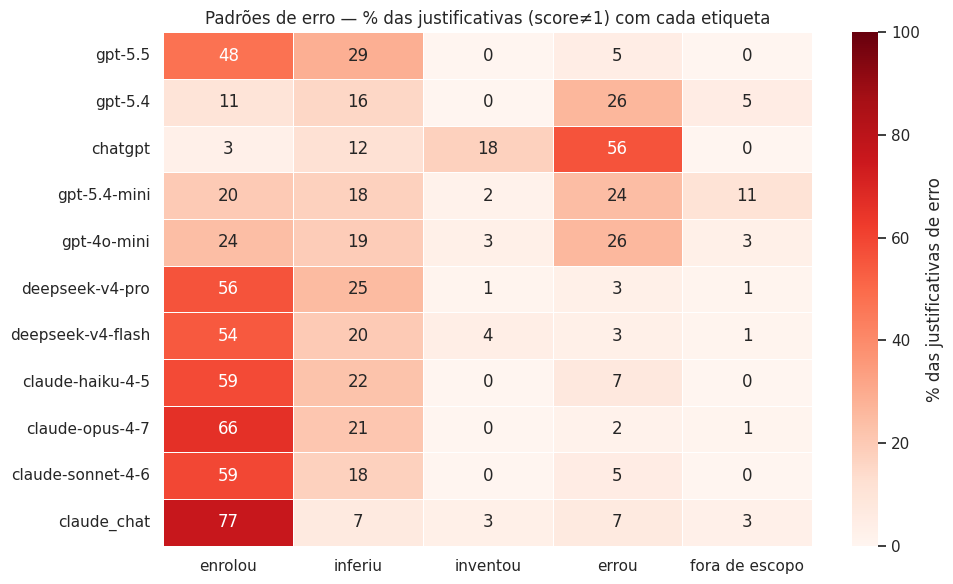


=== EXEMPLOS DE JUSTIFICATIVAS POR PADRÃO ===

[ENROLOU]  (total: 435)
  (claude-opus-4-7, cvm#41, score=0.5) item 9.7.1 e Anexo II definem 2 questões de 20 pontos; enrolou com regras não pedidas.
  (claude_chat, bndes#23, score=0.5) item 2.1 fixa salário e benefícios; resposta despejou regime, experiência e avaliações além da remuneração, enrolou
  (claude-haiku-4-5, cvm#2, score=0.5) item 4.1.1 fixa R$ 145,00; problema: enrolou com formas de pagamento, prazo e devolução não pedidos.

[INFERIU]  (total: 146)
  (claude-opus-4-7, bndes#46, score=0.5) Anexo III fixa 13/10/2024; resposta confere no núcleo, mas inferiu dado temporal fora do edital.
  (claude-sonnet-4-6, petrobras#13, score=0.5) item 11.5 fixa validade de 12 meses prorrogável; resposta confere no essencial, mas inferiu datas de expiração e situação atual.
  (claude_chat, bndes#30, score=0.5) item 2.1 traz atribuições gerais; resposta inventou atribuições específicas a partir de conteúdo programático e contexto, inferiu/enr

In [18]:
# Heatmap dos padrões — % das justificativas com score≠1 que contêm cada termo
pct = err_modelo[PADROES].div(err_modelo['total_erros'], axis=0).fillna(0) * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pct, annot=True, fmt='.0f', cmap='Reds', vmin=0, vmax=100,
            cbar_kws={'label': '% das justificativas de erro'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Padrões de erro — % das justificativas (score≠1) com cada etiqueta')
ax.set_xlabel(''); ax.set_ylabel('')
plt.tight_layout(); plt.show()

print('\n=== EXEMPLOS DE JUSTIFICATIVAS POR PADRÃO ===')
for p in PADROES:
    n = ruins[p].sum()
    if not n: continue
    samples = ruins[ruins[p] == 1].sample(min(3, n), random_state=42)
    print(f'\n[{p.upper()}]  (total: {n})')
    for _, r in samples.iterrows():
        print(f'  ({r.modelo}, {r.edital}#{r.id}, score={r.score}) {str(r.justificativa)[:200]}')


In [23]:
print(err_modelo.loc['gpt-5.5'])
print()
print(pct.loc['gpt-5.5'].round(1))

enrolou           10
inferiu            6
inventou           0
errou              1
fora de escopo     0
total_erros       21
Name: gpt-5.5, dtype: int64

enrolou           47.6
inferiu           28.6
inventou           0.0
errou              4.8
fora de escopo     0.0
Name: gpt-5.5, dtype: float64


## 10. Sumário final & exporte

In [19]:
sumario = ranking[['media', 'n']].copy()
sumario.columns = ['score_medio', 'n_avaliacoes']
sumario['%_certo']   = ranking['certo_%']
sumario['%_parcial'] = ranking['parcial_%']
sumario['%_errado']  = ranking['errado_%']
sumario = sumario.join(mat[EDITAIS + ['desvio']])
sumario = sumario.rename(columns={'bndes': 'bndes_media', 'cvm': 'cvm_media',
                                  'petrobras': 'petro_media', 'desvio': 'desvio_editais'})
sumario


,score_medio,n_avaliacoes,%_certo,%_parcial,%_errado,bndes_media,cvm_media,petro_media,desvio_editais
modelo,,,,,,,,,
gpt-5.5,0.930,150,86.0,14.0,0.0,0.94,0.92,0.93,0.010
gpt-5.4,0.927,150,87.3,10.7,2.0,0.92,0.89,0.97,0.040
chatgpt,0.833,150,77.3,12.0,10.7,0.66,0.97,0.87,0.158
gpt-5.4-mini,0.820,150,70.0,24.0,6.0,0.84,0.82,0.80,0.020
gpt-4o-mini,0.760,150,58.7,34.7,6.7,0.77,0.82,0.69,0.066
deepseek-v4-pro,0.693,150,39.3,60.0,0.7,0.77,0.68,0.63,0.071
deepseek-v4-flash,0.690,150,40.0,58.0,2.0,0.69,0.73,0.65,0.040
claude-haiku-4-5,0.677,150,37.3,60.7,2.0,0.72,0.71,0.60,0.067
claude-opus-4-7,0.673,150,34.7,65.3,0.0,0.77,0.63,0.62,0.084


In [20]:
out_path = OUT_DIR / 'analise_consolidada.xlsx'
with pd.ExcelWriter(out_path, engine='openpyxl') as w:
    df.to_excel(w, sheet_name='master_long', index=False)
    sumario.to_excel(w, sheet_name='sumario_modelo')
    mat.to_excel(w,     sheet_name='modelo_x_edital')
    mat_cat.to_excel(w, sheet_name='modelo_x_categoria')
    perg.sort_values('media').to_excel(w, sheet_name='perguntas_ranked', index=False)
    err_modelo.to_excel(w, sheet_name='padroes_erro')
print(f'salvo: {out_path}')


salvo: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/evals/avaliacao_chats_comerciais/analise_out/analise_consolidada.xlsx


In [21]:
gpt55_ruins = ruins[ruins['modelo'] == 'gpt-5.5'].sort_values('score')
print(f'total não-perfeitas: {len(gpt55_ruins)}')
print(f'distribuição: {gpt55_ruins.score.value_counts().to_dict()}')

# 10 exemplos de "enrolou" - lê as justificativas, decide se faz sentido
for _, r in gpt55_ruins[gpt55_ruins['enrolou'] == 1].head(10).iterrows():
    print(f'\n[{r.edital}#{r.id}, score={r.score}] {r.justificativa}')

total não-perfeitas: 21
distribuição: {0.5: 21}

[bndes#1, score=0.5] item 6.2.1 fixa inscrição de 10h de 26/07/2024 a 23h59 de 19/08/2024; resposta confere, mas enrolou com dados não pedidos.

[bndes#6, score=0.5] itens 6.6.1 e 6.7 restringem a isenção a CadÚnico de baixa renda ou doador de medula óssea; resposta confere, mas enrolou com dados não pedidos.

[bndes#7, score=0.5] item 6.7 fixa a solicitação de isenção de 26/07 a 02/08/2024; resposta confere, mas enrolou com dados não pedidos.

[bndes#10, score=0.5] itens 7.1 e 9.4 exigem imprimir/levar o Cartão de Confirmação, mas não exigem guardar comprovante de pagamento; resposta confere em parte, mas enrolou com dados não pedidos.

[bndes#13, score=0.5] item 1.7 fixa validade de 2 anos contados da homologação; enrolou com data atual e cronograma não necessários.

[cvm#13, score=0.5] item 1.2 fixa o prazo; resposta confere, mas enrolou com data atual não pedida.

[cvm#17, score=0.5] item 2.5 prevê a impugnação; resposta confere, mas

In [22]:
print('err_modelo (contagem absoluta):')
print(err_modelo.loc['gpt-5.5'])

print('\npct (percentual sobre total_erros):')
print(pct.loc['gpt-5.5'].round(1))

err_modelo (contagem absoluta):
enrolou           10
inferiu            6
inventou           0
errou              1
fora de escopo     0
total_erros       21
Name: gpt-5.5, dtype: int64

pct (percentual sobre total_erros):
enrolou           47.6
inferiu           28.6
inventou           0.0
errou              4.8
fora de escopo     0.0
Name: gpt-5.5, dtype: float64
